# Plot multi-lead predictions for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
%matplotlib inline
%load_ext autotime

import sys
import importlib as imp
import warnings
from shapely.errors import ShapelyDeprecationWarning

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal
from silence_tensorflow import silence_tensorflow
import pandas as pd
import cartopy as ct
import plots

import experiment_settings
import mahalanobis
from build_data import build_data
import data_info

time: 2.3 s (started: 2022-12-13 14:37:12 -07:00)


In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "13 December 2022"

DATA_PATH = "data/"
MODEL_PATH = "saved_models/"
FIGURE_PATH = "figures/analysis/"
PREDICTIONS_PATH = "saved_predictions/"

time: 245 µs (started: 2022-12-13 14:37:15 -07:00)


In [3]:
plt.style.use("seaborn-white")
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams["figure.dpi"] = 100
dpiFig = 600
plots.set_plot_rc()
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

time: 447 µs (started: 2022-12-13 14:37:15 -07:00)


In [4]:
EXP_NAME_VEC = (
    # "centered_bivariate_normal_000_EPCP24",

    "centered_bivariate_normal_100_EPCP12",
    "centered_bivariate_normal_101_EPCP24",
    "centered_bivariate_normal_102_EPCP36",
    "centered_bivariate_normal_103_EPCP48",
    "centered_bivariate_normal_104_EPCP60",
    "centered_bivariate_normal_105_EPCP72",
    "centered_bivariate_normal_106_EPCP84",
    "centered_bivariate_normal_107_EPCP96",
    "centered_bivariate_normal_108_EPCP108",
    "centered_bivariate_normal_109_EPCP120",

    "centered_bivariate_normal_200_AL12",
    "centered_bivariate_normal_201_AL24",
    "centered_bivariate_normal_202_AL36",
    "centered_bivariate_normal_203_AL48",
    "centered_bivariate_normal_204_AL60",
    "centered_bivariate_normal_205_AL72",
    "centered_bivariate_normal_206_AL84",
    "centered_bivariate_normal_207_AL96",
    "centered_bivariate_normal_208_AL108",
    "centered_bivariate_normal_209_AL120",

    )

# Ian
RNG_SEED = 1
TESTING_YEAR = 2022

# Norman
# RNG_SEED = 1
# TESTING_YEAR = 2018

time: 437 µs (started: 2022-12-13 14:37:15 -07:00)


In [5]:
# GET PREDICTIONS
df_pred_test = pd.DataFrame()

for exp_name in EXP_NAME_VEC:
    print(exp_name)
    settings = experiment_settings.get_settings(exp_name)

    # Create the model name.
    model_name = (
            exp_name
            + "_"
            + str(TESTING_YEAR)
            + "_"
            + settings["uncertainty_type"]
            + "_"
            + f"rng_seed_{RNG_SEED}"
    )
    try:
        prediction_filename = PREDICTIONS_PATH + model_name + "_testing_predictions.csv"
        df = pd.read_csv(prediction_filename)
    except:
        continue

    settings["rng_seed"] = RNG_SEED
    settings["years_test"] = (TESTING_YEAR,)
    df["exp_name"] = exp_name
    df_pred_test = pd.concat([df_pred_test, df], axis=0)

centered_bivariate_normal_100_EPCP12
centered_bivariate_normal_101_EPCP24
centered_bivariate_normal_102_EPCP36
centered_bivariate_normal_103_EPCP48
centered_bivariate_normal_104_EPCP60
centered_bivariate_normal_105_EPCP72
centered_bivariate_normal_106_EPCP84
centered_bivariate_normal_107_EPCP96
centered_bivariate_normal_108_EPCP108
centered_bivariate_normal_109_EPCP120
centered_bivariate_normal_200_AL12
centered_bivariate_normal_201_AL24
centered_bivariate_normal_202_AL36
centered_bivariate_normal_203_AL48
centered_bivariate_normal_204_AL60
centered_bivariate_normal_205_AL72
centered_bivariate_normal_206_AL84
centered_bivariate_normal_207_AL96
centered_bivariate_normal_208_AL108
centered_bivariate_normal_209_AL120
time: 39.3 ms (started: 2022-12-13 14:37:15 -07:00)


# Plot Results

In [6]:
df_pred_test[df_pred_test["Name"]=="IAN"].sort_index()

,Unnamed: 0,ATCF,Name,year,time,ftime(hr),VMAX0,NCI,VMAXN,OFDV,...,LATC,PREDICTAND_X,PREDICTAND_Y,mu_u,mu_v,sigma_u,sigma_v,rho,euclidian_error,exp_name
0,0,AL09,IAN,2022,92412,48,40.0,4,85.0,-15.0,...,18.7,-10.5,-11.1,-0.0,-0.0,85.645920,77.658516,-0.055705,15.279398,centered_bivariate_normal_203_AL48
1,1,AL09,IAN,2022,92612,72,70.0,4,90.0,-30.0,...,27.5,254.6,44.4,-0.0,0.0,90.441560,63.935680,-0.158203,258.442500,centered_bivariate_normal_205_AL72
2,2,AL09,IAN,2022,92312,12,30.0,4,35.0,0.0,...,14.6,10.7,33.3,-0.0,0.0,42.225704,41.790874,0.097752,34.976850,centered_bivariate_normal_200_AL12
3,3,AL09,IAN,2022,92712,48,110.0,4,75.0,-15.0,...,27.8,147.0,66.7,-0.0,-0.0,112.165764,106.492775,0.166989,161.424560,centered_bivariate_normal_203_AL48
3,3,AL09,IAN,2022,92400,120,35.0,4,95.0,5.0,...,27.3,29.5,-88.9,-0.0,0.0,181.777300,129.104350,0.006481,93.666750,centered_bivariate_normal_209_AL120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,164,AL09,IAN,2022,92700,24,85.0,4,120.0,-15.0,...,24.4,70.8,-11.1,-0.0,0.0,31.527506,31.468750,0.184683,71.664850,centered_bivariate_normal_201_AL24
166,166,AL09,IAN,2022,92512,24,45.0,4,70.0,0.0,...,18.4,10.5,66.7,-0.0,0.0,50.408615,50.698170,0.024238,67.521400,centered_bivariate_normal_201_AL24
167,167,AL09,IAN,2022,92400,12,35.0,4,40.0,0.0,...,14.7,-64.5,-33.3,-0.0,0.0,33.360140,33.164337,0.105044,72.588844,centered_bivariate_normal_200_AL12
184,184,AL09,IAN,2022,92818,12,135.0,4,75.0,-15.0,...,27.7,49.2,-11.1,-0.0,0.0,23.522186,23.638330,0.107953,50.436596,centered_bivariate_normal_200_AL12


time: 13.8 ms (started: 2022-12-13 14:37:15 -07:00)


60 dataframe is empty
84 dataframe is empty
108 dataframe is empty


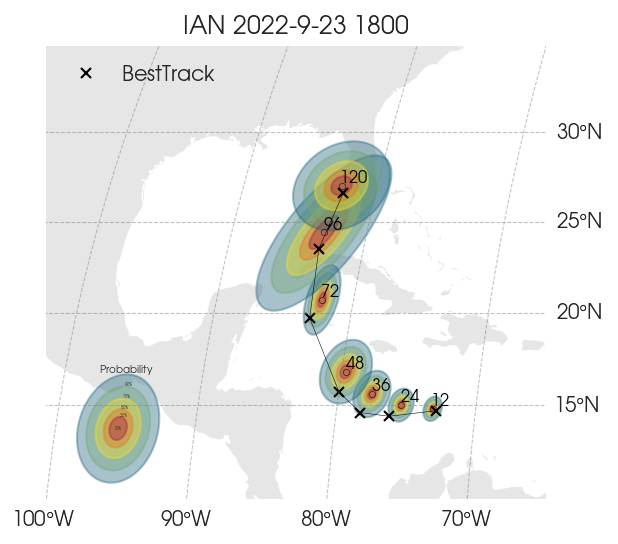

time: 10.3 s (started: 2022-12-13 14:37:15 -07:00)


In [7]:
imp.reload(mahalanobis)
imp.reload(plots)

fig = plt.figure(dpi=150, )
ax = fig.add_subplot(1, 1, 1, projection=ct.crs.EqualEarth(central_longitude=0.))

# storm = {
#     "storm_name": "NORMAN",
#     "pred_time": 90306,
#     "extent": [195, 360-135, 5, 35],
#     }
# storm = {"storm_name": "MICHAEL",
#          "pred_time": 100718,
#          "extent": [-100,-70,15,45],
#          }
if TESTING_YEAR == 2022:
    storm = {"storm_name": "IAN",
             "pred_time": 92318,
             "extent": [-100,-70,10,35],
        }
elif TESTING_YEAR == 2018:
    storm = {"storm_name": "NORMAN",
             "pred_time": 90306,
             "extent": [195, 360-135, 5, 35],
        }
else:
    raise NotImplementedError('no such storm to plot')

df_storm = df_pred_test.loc[
    (df_pred_test["Name"] == storm["storm_name"]) & (df_pred_test["time"] == storm["pred_time"])]
details = plots.plot_leadtime_predictions(
    df_storm,
    ax=ax,
    leadtimes=np.arange(12,120+12, 12),
    # contours=(.25, .5, .75,),
    contours=(.1, .25, .5, .75, .9,),
    extent = storm["extent"],
    )
# ax.set_global()
ax.set_extent(storm["extent"], crs=ct.crs.PlateCarree())

# save the figure
plt.savefig(
    FIGURE_PATH + 'multi_lead_predictions_' + EXP_NAME_VEC[0] + '_' + details.replace(' ', '_') + '.png',
    dpi=dpiFig,
    bbox_inches='tight',
    )
plt.show()

time: 10.3 s (started: 2022-12-13 14:37:15 -07:00)
